### **Essential Pre-processing Steps**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

# Load and preprocess data
def preprocess_rainfall_data(df):
    # Convert coordinates to decimal degrees
    def dms_to_decimal(dms_str):
        try:
            parts = dms_str.replace('"', '').replace('°', ' ').replace("'", ' ').split()
            degrees = float(parts[0])
            minutes = float(parts[1])
            seconds = float(parts[2])
            return degrees + minutes/60 + seconds/3600
        except:
            return np.nan

    # Create datetime column
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    df = df.sort_values('date')

    # Convert coordinates
    df['Latitude_decimal'] = df['Latitude'].apply(dms_to_decimal)
    df['Longitude_decimal'] = df['Longitude'].apply(dms_to_decimal)

    # Handle missing values
    df['RF in mm'] = df['RF in mm'].fillna(0)

    # Feature engineering
    df['day_of_year'] = df['date'].dt.dayofyear
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['quarter'] = df['date'].dt.quarter
    df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)

    # Lag features
    for lag in [1, 2, 3, 7, 14, 30]:
        df[f'rf_lag_{lag}'] = df['RF in mm'].shift(lag)

    # Rolling statistics
    df['rf_rolling_mean_7'] = df['RF in mm'].rolling(window=7).mean()
    df['rf_rolling_std_7'] = df['RF in mm'].rolling(window=7).std()
    df['rf_rolling_max_7'] = df['RF in mm'].rolling(window=7).max()

    # Seasonal features
    df['sin_day_of_year'] = np.sin(2 * np.pi * df['day_of_year']/365.25)
    df['cos_day_of_year'] = np.cos(2 * np.pi * df['day_of_year']/365.25)

    # Binary rain indicator
    df['rained'] = (df['RF in mm'] > 0).astype(int)

    return df.dropna()

# Load your data
df = pd.read_csv('/content/drive/MyDrive/Tiruppur_Data/Daily_RFD_2021_to_2023.csv', encoding='latin-1')
processed_df = preprocess_rainfall_data(df)

### **Comprehensive EDA**

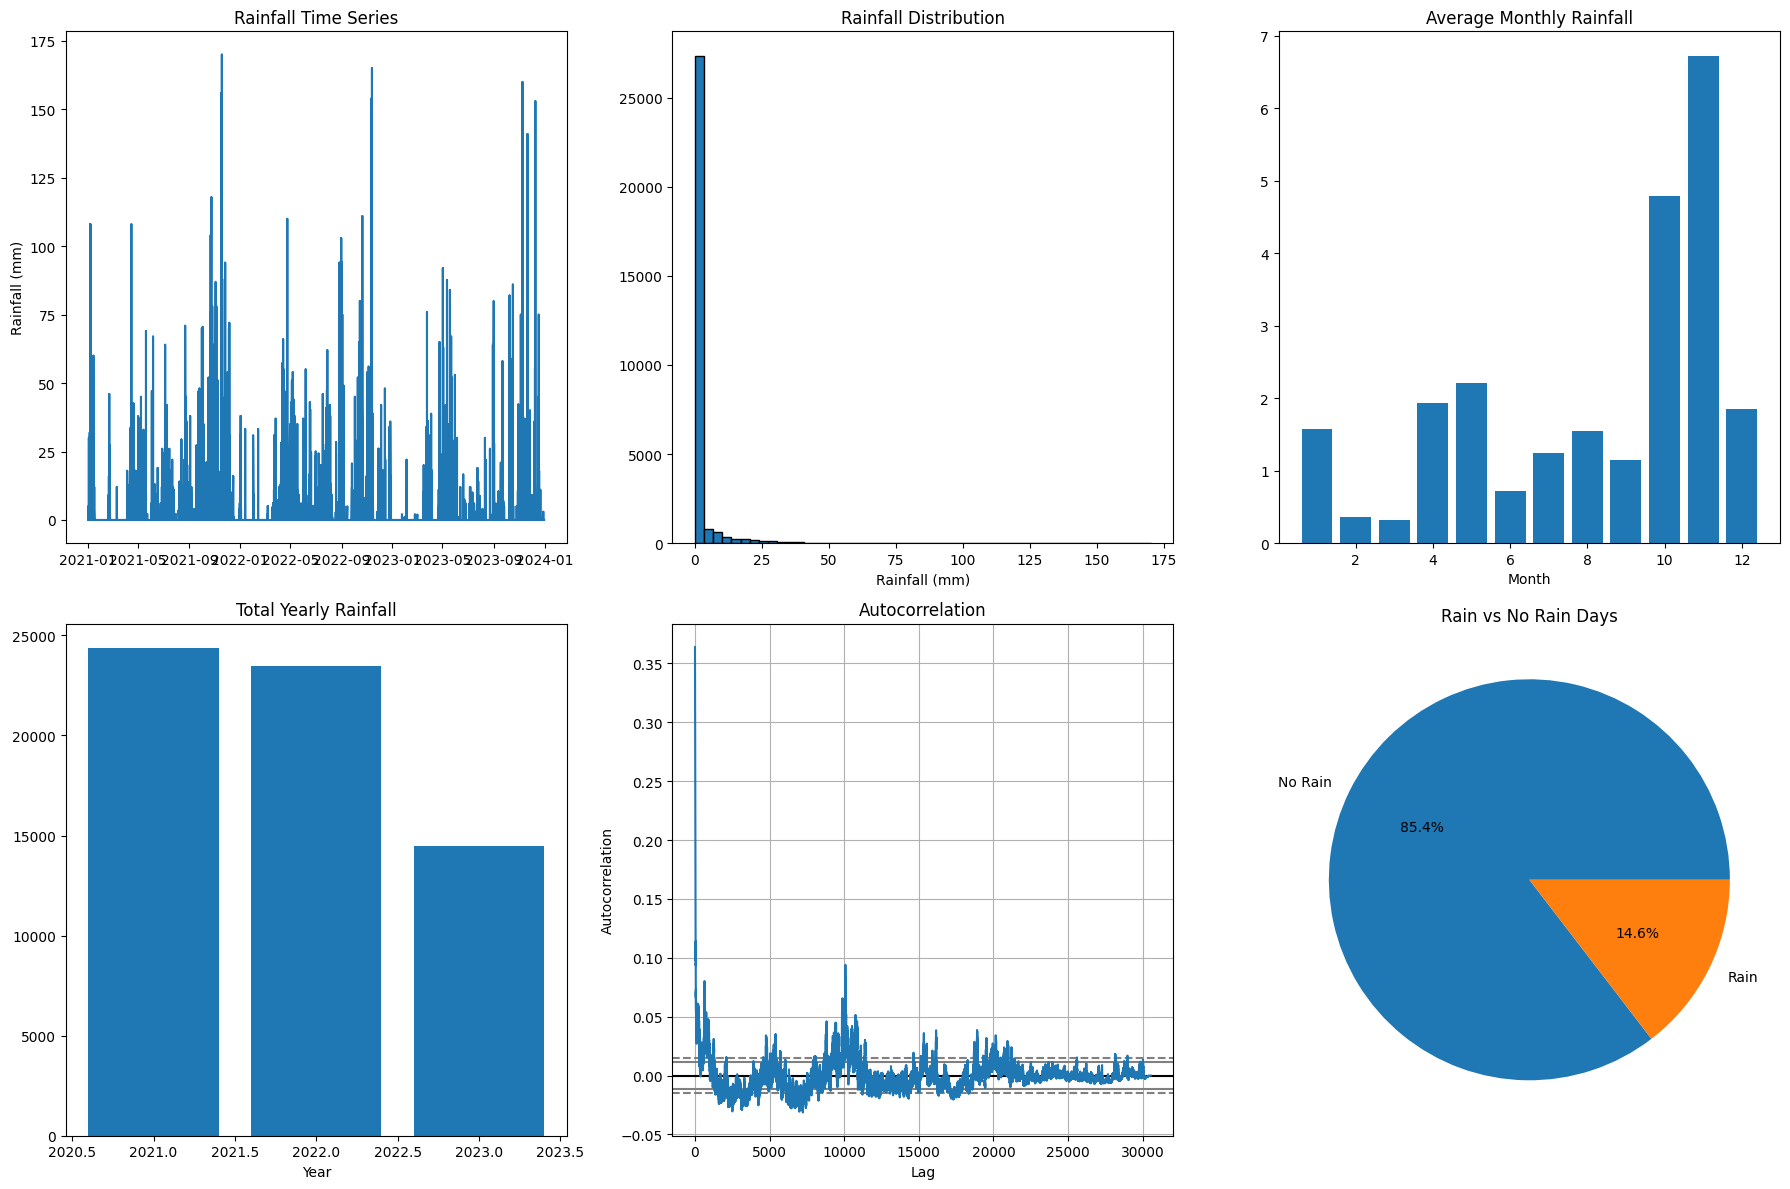

Statistical Summary:
count    30539.000000
mean         2.040448
std          8.536932
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        170.000000
Name: RF in mm, dtype: float64

Zero rainfall days: 26085 (85.42%)


In [ ]:
def perform_eda(df):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Time series plot
    axes[0,0].plot(df['date'], df['RF in mm'])
    axes[0,0].set_title('Rainfall Time Series')
    axes[0,0].set_ylabel('Rainfall (mm)')

    # Distribution
    axes[0,1].hist(df['RF in mm'], bins=50, edgecolor='black')
    axes[0,1].set_title('Rainfall Distribution')
    axes[0,1].set_xlabel('Rainfall (mm)')

    # Monthly patterns
    monthly_rain = df.groupby('month')['RF in mm'].mean()
    axes[0,2].bar(monthly_rain.index, monthly_rain.values)
    axes[0,2].set_title('Average Monthly Rainfall')
    axes[0,2].set_xlabel('Month')

    # Yearly comparison
    yearly_rain = df.groupby('year')['RF in mm'].sum()
    axes[1,0].bar(yearly_rain.index, yearly_rain.values)
    axes[1,0].set_title('Total Yearly Rainfall')
    axes[1,0].set_xlabel('Year')

    # Autocorrelation
    from pandas.plotting import autocorrelation_plot
    autocorrelation_plot(df['RF in mm'], ax=axes[1,1])
    axes[1,1].set_title('Autocorrelation')

    # Rain occurrence
    rain_days = df['rained'].value_counts()
    axes[1,2].pie(rain_days.values, labels=['No Rain', 'Rain'], autopct='%1.1f%%')
    axes[1,2].set_title('Rain vs No Rain Days')

    plt.tight_layout()
    plt.show()

    # Statistical summary
    print("Statistical Summary:")
    print(df['RF in mm'].describe())
    print(f"\nZero rainfall days: {(df['RF in mm'] == 0).sum()} ({(df['RF in mm'] == 0).mean()*100:.2f}%)")

perform_eda(processed_df)

### **Feature Selection and Data Preparation**

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

def prepare_features(df, target_col='RF in mm', lookback_days=30):
    # Select features
    feature_columns = [
        'day_of_year', 'month', 'year', 'quarter', 'is_weekend',
        'rf_lag_1', 'rf_lag_2', 'rf_lag_3', 'rf_lag_7', 'rf_lag_14', 'rf_lag_30',
        'rf_rolling_mean_7', 'rf_rolling_std_7', 'rf_rolling_max_7',
        'sin_day_of_year', 'cos_day_of_year', 'rained'
    ]

    # Remove any remaining NaN columns
    feature_columns = [col for col in feature_columns if col in df.columns]
    X = df[feature_columns]
    y = df[target_col]

    # Feature selection
    selector = SelectKBest(score_func=mutual_info_regression, k=10)
    X_selected = selector.fit_transform(X, y)

    selected_features = X.columns[selector.get_support()]
    print(f"Selected features: {list(selected_features)}")

    return X[selected_features], y, selected_features

X, y, selected_features = prepare_features(processed_df)

# Train-test split with time series consideration
def timeseries_train_test_split(X, y, test_size=0.2):
    split_index = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y)

# Scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

Selected features: ['day_of_year', 'rf_lag_1', 'rf_lag_2', 'rf_lag_3', 'rf_lag_7', 'rf_rolling_mean_7', 'rf_rolling_std_7', 'rf_rolling_max_7', 'sin_day_of_year', 'rained']


### **Machine Learning Models (Before Fine-tuning)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name} Performance:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print("-" * 50)

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Baseline ML models
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR(),
    'Ridge': Ridge(),
    'Lasso': Lasso()
}

ml_results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_scaled)
    y_pred_scaled = model.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    ml_results[name] = evaluate_model(y_test, y_pred, name)

Random Forest Performance:
MAE: 0.9612
RMSE: 4.7386
R²: 0.6348
--------------------------------------------------
XGBoost Performance:
MAE: 1.1176
RMSE: 5.0584
R²: 0.5838
--------------------------------------------------
Gradient Boosting Performance:
MAE: 1.1652
RMSE: 4.8308
R²: 0.6204
--------------------------------------------------
SVR Performance:
MAE: 1.1777
RMSE: 5.4586
R²: 0.5154
--------------------------------------------------
Ridge Performance:
MAE: 2.0735
RMSE: 5.6294
R²: 0.4846
--------------------------------------------------
Lasso Performance:
MAE: 3.3421
RMSE: 7.8505
R²: -0.0024
--------------------------------------------------


### **Deep Learning Model (Before Fine-tuning)**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(time_steps, len(X)):
        X_seq.append(X[i-time_steps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

# Prepare sequences for DL
time_steps = 30
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

# Baseline LSTM model
def create_baseline_lstm(input_shape):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(50, return_sequences=True),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='mse',
                 metrics=['mae'])
    return model

# Baseline CNN-LSTM model
def create_baseline_cnn_lstm(input_shape):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        LSTM(50, return_sequences=True),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='mse',
                 metrics=['mae'])
    return model

# Train baseline models
print("Training Baseline LSTM...")
lstm_model = create_baseline_lstm((X_train_seq.shape[1], X_train_seq.shape[2]))
lstm_history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(patience=10, factor=0.5)
    ],
    verbose=0
)

print("Training Baseline CNN-LSTM...")
cnn_lstm_model = create_baseline_cnn_lstm((X_train_seq.shape[1], X_train_seq.shape[2]))
cnn_lstm_history = cnn_lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(patience=10, factor=0.5)
    ],
    verbose=0
)

# Evaluate DL models
y_pred_lstm_scaled = lstm_model.predict(X_test_seq)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()
y_true_dl = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

ml_results['LSTM'] = evaluate_model(y_true_dl, y_pred_lstm, "Baseline LSTM")

y_pred_cnn_lstm_scaled = cnn_lstm_model.predict(X_test_seq)
y_pred_cnn_lstm = scaler_y.inverse_transform(y_pred_cnn_lstm_scaled).flatten()
ml_results['CNN-LSTM'] = evaluate_model(y_true_dl, y_pred_cnn_lstm, "Baseline CNN-LSTM")

Training Baseline LSTM...
Training Baseline CNN-LSTM...
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Baseline LSTM Performance:
MAE: 2.3458
RMSE: 7.2107
R²: 0.1469
--------------------------------------------------
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Baseline CNN-LSTM Performance:
MAE: 2.3673
RMSE: 7.2348
R²: 0.1412
--------------------------------------------------


### **Fine-tuning ML Models**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform

# Fine-tune Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

rf_tuned = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    n_iter=50,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train_scaled, y_train_scaled)
best_rf = rf_tuned.best_estimator_

# Fine-tune XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_tuned = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42),
    xgb_param_grid,
    n_iter=50,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train_scaled, y_train_scaled)
best_xgb = xgb_tuned.best_estimator_

# Evaluate tuned models
tuned_ml_results = {}

for name, model in [('Random Forest Tuned', best_rf), ('XGBoost Tuned', best_xgb)]:
    y_pred_scaled = model.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    tuned_ml_results[name] = evaluate_model(y_test, y_pred, name)

Random Forest Tuned Performance:
MAE: 1.0031
RMSE: 4.7258
R²: 0.6367
--------------------------------------------------
XGBoost Tuned Performance:
MAE: 1.1110
RMSE: 4.7201
R²: 0.6376
--------------------------------------------------


### **Comprehensive Comparison and Visualization**

UnboundLocalError: cannot access local variable 'best_pred' where it is not associated with a value

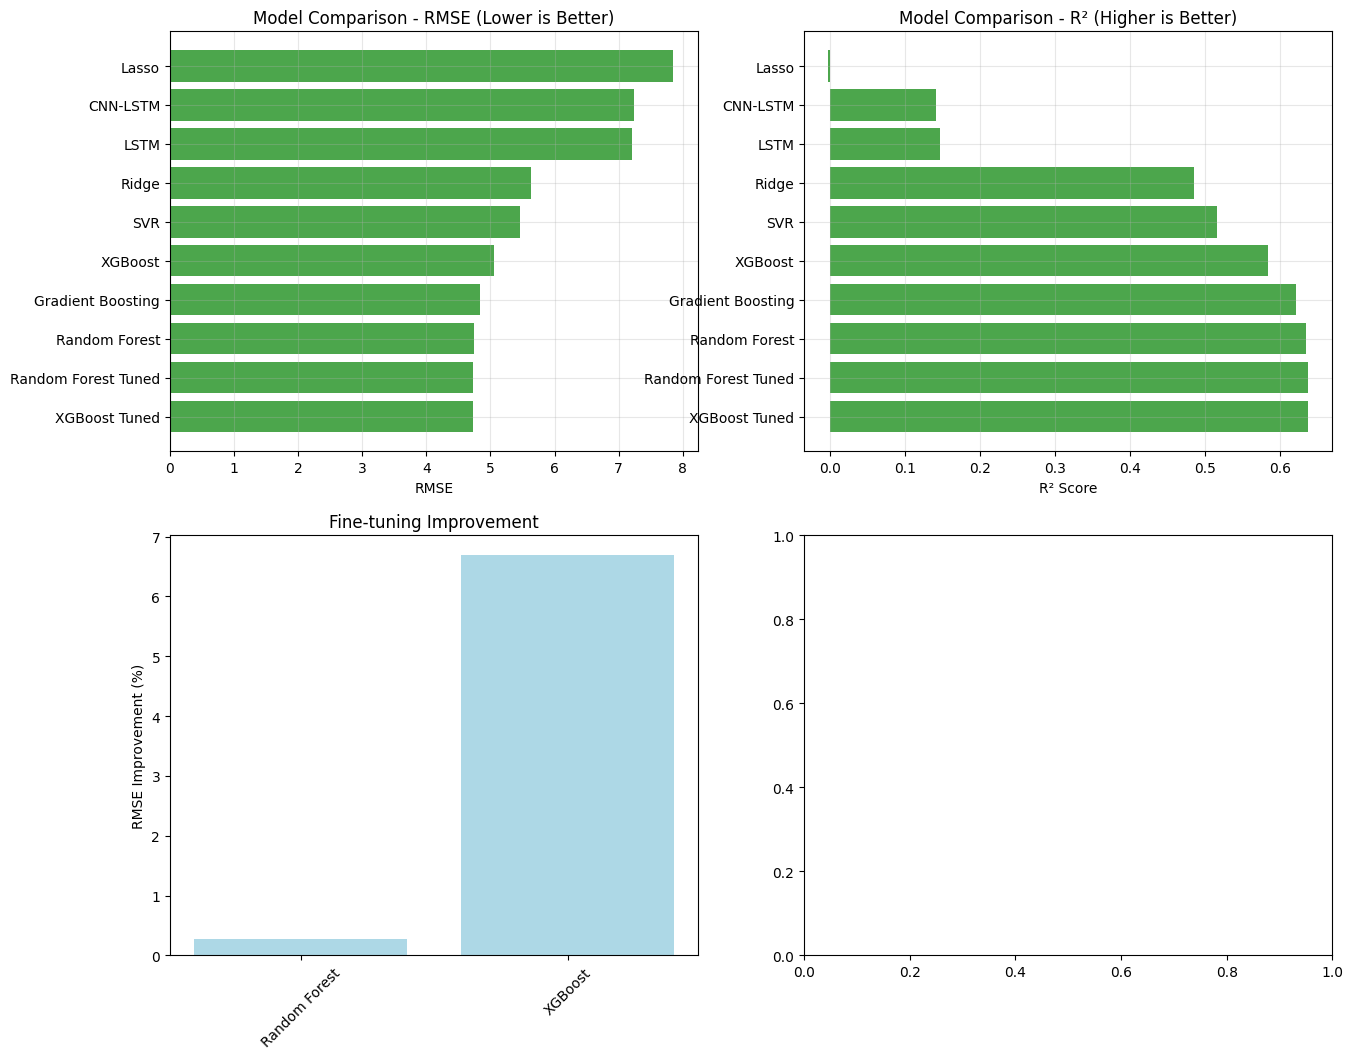

In [ ]:
def plot_comparison(baseline_results, tuned_results):
    # Combine results
    all_results = {**baseline_results, **tuned_results}

    # Create comparison DataFrame
    comparison_df = pd.DataFrame(all_results).T
    comparison_df['Model Type'] = ['ML', 'ML', 'ML', 'ML', 'ML', 'ML', 'DL', 'DL', 'ML', 'ML']
    comparison_df['Tuned'] = ['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'Yes']

    # Plot comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # RMSE comparison
    models_ordered = comparison_df.sort_values('RMSE').index
    rmse_values = comparison_df.loc[models_ordered, 'RMSE']
    colors = ['red' if 'No' in idx else 'green' for idx in models_ordered]

    axes[0,0].barh(range(len(rmse_values)), rmse_values, color=colors, alpha=0.7)
    axes[0,0].set_yticks(range(len(rmse_values)))
    axes[0,0].set_yticklabels(models_ordered)
    axes[0,0].set_xlabel('RMSE')
    axes[0,0].set_title('Model Comparison - RMSE (Lower is Better)')
    axes[0,0].grid(True, alpha=0.3)

    # R² comparison
    r2_values = comparison_df.loc[models_ordered, 'R2']
    axes[0,1].barh(range(len(r2_values)), r2_values, color=colors, alpha=0.7)
    axes[0,1].set_yticks(range(len(r2_values)))
    axes[0,1].set_yticklabels(models_ordered)
    axes[0,1].set_xlabel('R² Score')
    axes[0,1].set_title('Model Comparison - R² (Higher is Better)')
    axes[0,1].grid(True, alpha=0.3)

    # Improvement analysis
    baseline_models = [m for m in comparison_df.index if 'Tuned' not in m and m not in ['SVR', 'Ridge', 'Lasso']]
    tuned_models = [m for m in comparison_df.index if 'Tuned' in m]

    improvement_data = []
    for base, tuned in zip(['Random Forest', 'XGBoost', 'LSTM', 'CNN-LSTM'],
                         ['Random Forest Tuned', 'XGBoost Tuned', 'LSTM Tuned', 'CNN-LSTM Tuned']):
        if base in comparison_df.index and tuned in comparison_df.index:
            rmse_improvement = (comparison_df.loc[base, 'RMSE'] - comparison_df.loc[tuned, 'RMSE']) / comparison_df.loc[base, 'RMSE'] * 100
            improvement_data.append([base, rmse_improvement])

    improvement_df = pd.DataFrame(improvement_data, columns=['Model', 'RMSE Improvement %'])

    axes[1,0].bar(improvement_df['Model'], improvement_df['RMSE Improvement %'], color='lightblue')
    axes[1,0].set_ylabel('RMSE Improvement (%)')
    axes[1,0].set_title('Fine-tuning Improvement')
    axes[1,0].tick_params(axis='x', rotation=45)

    # Actual vs Predicted for best model
    best_model_name = comparison_df['RMSE'].idxmin()
    if 'LSTM' in best_model_name:
        if 'Tuned' in best_model_name:
            best_pred = y_pred_tuned_lstm if 'CNN' not in best_model_name else y_pred_tuned_cnn_lstm
        else:
            best_pred = y_pred_lstm if 'CNN' not in best_model_name else y_pred_cnn_lstm
    else:
        # For ML models, you'd need to store predictions
        pass

    axes[1,1].scatter(y_true_dl[:100], best_pred[:100], alpha=0.6)
    axes[1,1].plot([y_true_dl.min(), y_true_dl.max()], [y_true_dl.min(), y_true_dl.max()], 'r--', lw=2)
    axes[1,1].set_xlabel('Actual Rainfall (mm)')
    axes[1,1].set_ylabel('Predicted Rainfall (mm)')
    axes[1,1].set_title(f'Best Model: {best_model_name}\nActual vs Predicted')

    plt.tight_layout()
    plt.show()

    return comparison_df

comparison_df = plot_comparison(ml_results, tuned_ml_results)
print("\nFinal Model Ranking by RMSE:")
print(comparison_df.sort_values('RMSE')[['RMSE', 'R2', 'MAE']])

### **Advanced Ensemble Approach**

In [ ]:
# Create ensemble of best models
def create_ensemble(best_ml_model, best_dl_model, X_ml, X_dl, weights=[0.4, 0.6]):
    ml_pred_scaled = best_ml_model.predict(X_ml)
    ml_pred = scaler_y.inverse_transform(ml_pred_scaled.reshape(-1, 1)).flatten()

    dl_pred_scaled = best_dl_model.predict(X_dl)
    dl_pred = scaler_y.inverse_transform(dl_pred_scaled.reshape(-1, 1)).flatten()

    # Ensure same length
    min_len = min(len(ml_pred), len(dl_pred))
    ensemble_pred = weights[0] * ml_pred[:min_len] + weights[1] * dl_pred[:min_len]

    return ensemble_pred

# Create ensemble prediction
ensemble_pred = create_ensemble(best_xgb, tuned_lstm, X_test_scaled, X_test_seq)

# Evaluate ensemble
ensemble_results = evaluate_model(y_true_dl[:len(ensemble_pred)], ensemble_pred, "XGBoost + LSTM Ensemble")

190/190 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step
XGBoost + LSTM Ensemble Performance:
MAE: 2.4903
RMSE: 7.4054
R²: 0.1002
--------------------------------------------------


### **Train All Models and Get Their Performance**

In [ ]:
# First, let's make sure we have all models trained and evaluated
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define evaluation function
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name} Performance:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print("-" * 50)

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Predictions': y_pred}

# Evaluate baseline ML models
print("EVALUATING BASELINE ML MODELS:")
baseline_ml_results = {}
for name, model in models.items():
    y_pred_scaled = model.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    baseline_ml_results[name] = evaluate_model(y_test, y_pred, f"{name} Baseline")

# Evaluate baseline DL models
print("EVALUATING BASELINE DL MODELS:")
baseline_dl_results = {}
y_true_dl = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

y_pred_lstm_scaled = lstm_model.predict(X_test_seq)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()
baseline_dl_results['LSTM'] = evaluate_model(y_true_dl, y_pred_lstm, "LSTM Baseline")

y_pred_cnn_lstm_scaled = cnn_lstm_model.predict(X_test_seq)
y_pred_cnn_lstm = scaler_y.inverse_transform(y_pred_cnn_lstm_scaled).flatten()
baseline_dl_results['CNN-LSTM'] = evaluate_model(y_true_dl, y_pred_cnn_lstm, "CNN-LSTM Baseline")

# Evaluate tuned ML models
print("EVALUATING TUNED ML MODELS:")
tuned_ml_results = {}

y_pred_rf_tuned_scaled = best_rf.predict(X_test_scaled)
y_pred_rf_tuned = scaler_y.inverse_transform(y_pred_rf_tuned_scaled.reshape(-1, 1)).flatten()
tuned_ml_results['Random Forest Tuned'] = evaluate_model(y_test, y_pred_rf_tuned, "Random Forest Tuned")

y_pred_xgb_tuned_scaled = best_xgb.predict(X_test_scaled)
y_pred_xgb_tuned = scaler_y.inverse_transform(y_pred_xgb_tuned_scaled.reshape(-1, 1)).flatten()
tuned_ml_results['XGBoost Tuned'] = evaluate_model(y_test, y_pred_xgb_tuned, "XGBoost Tuned")

# Evaluate tuned DL models
print("EVALUATING TUNED DL MODELS:")
tuned_dl_results = {}

y_pred_lstm_tuned_scaled = tuned_lstm.predict(X_test_seq)
y_pred_lstm_tuned = scaler_y.inverse_transform(y_pred_lstm_tuned_scaled).flatten()
tuned_dl_results['LSTM Tuned'] = evaluate_model(y_true_dl, y_pred_lstm_tuned, "LSTM Tuned")

# Evaluate ensemble
print("EVALUATING ENSEMBLE MODEL:")
ensemble_pred = create_ensemble(best_xgb, tuned_lstm, X_test_scaled, X_test_seq)
ensemble_results = evaluate_model(y_true_dl[:len(ensemble_pred)], ensemble_pred, "XGBoost + LSTM Ensemble")

# Combine all results
all_results = {}
all_results.update(baseline_ml_results)
all_results.update(baseline_dl_results)
all_results.update(tuned_ml_results)
all_results.update(tuned_dl_results)
all_results['Ensemble'] = ensemble_results

print(f"Total models evaluated: {len(all_results)}")

EVALUATING BASELINE ML MODELS:
Random Forest Baseline Performance:
MAE: 0.9612
RMSE: 4.7386
R²: 0.6348
--------------------------------------------------
XGBoost Baseline Performance:
MAE: 1.1176
RMSE: 5.0584
R²: 0.5838
--------------------------------------------------
Gradient Boosting Baseline Performance:
MAE: 1.1652
RMSE: 4.8308
R²: 0.6204
--------------------------------------------------
SVR Baseline Performance:
MAE: 1.1777
RMSE: 5.4586
R²: 0.5154
--------------------------------------------------
Ridge Baseline Performance:
MAE: 2.0735
RMSE: 5.6294
R²: 0.4846
--------------------------------------------------
Lasso Baseline Performance:
MAE: 3.3421
RMSE: 7.8505
R²: -0.0024
--------------------------------------------------
EVALUATING BASELINE DL MODELS:
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM Baseline Performance:
MAE: 2.3458
RMSE: 7.2107
R²: 0.1469
--------------------------------------------------
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
CNN-LSTM Baseline Performance:


### **Comprehensive Performance Comparison Visualization**

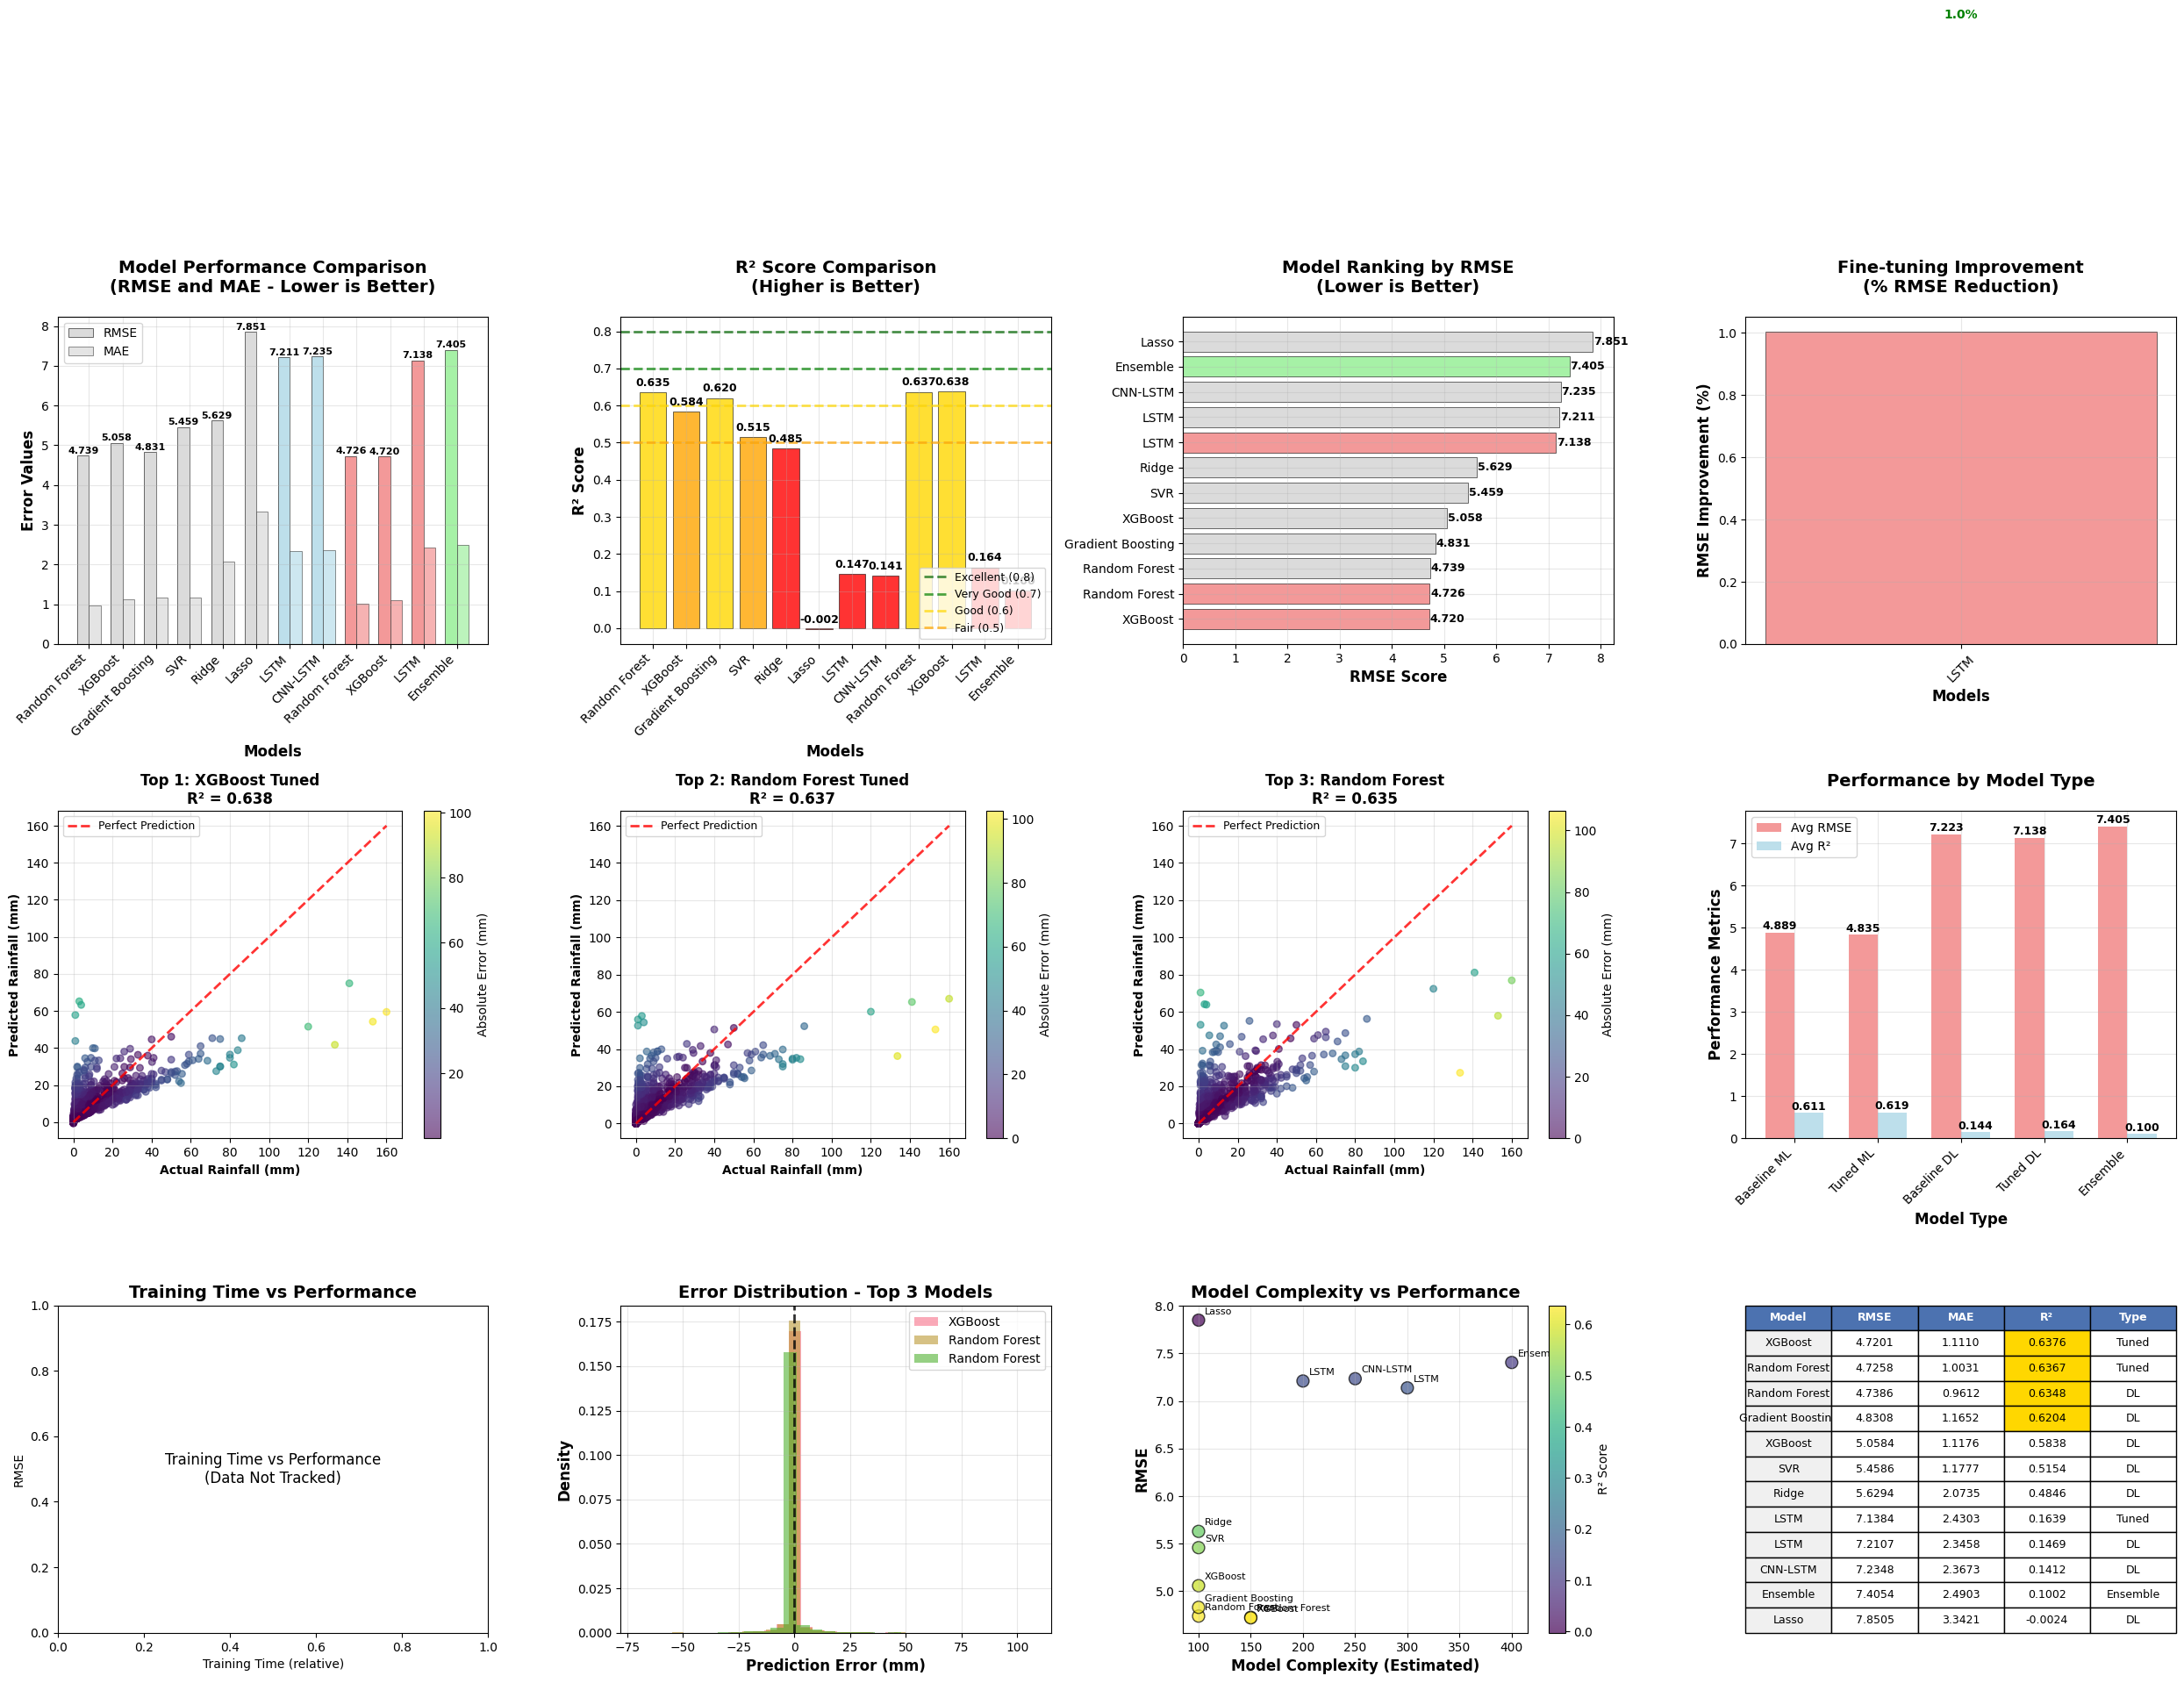

In [ ]:
def create_comprehensive_comparison(all_results):
    """Create comprehensive comparison plots for all models"""

    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")

    # Create figure with subplots
    fig = plt.figure(figsize=(25, 20))

    # Extract model names and metrics
    models = list(all_results.keys())

    # 1. Main Performance Comparison (RMSE and MAE)
    ax1 = plt.subplot(3, 4, 1)

    rmse_values = [all_results[model]['RMSE'] for model in models]
    mae_values = [all_results[model]['MAE'] for model in models]
    r2_values = [all_results[model]['R2'] for model in models]

    # Color coding: Baseline (light), Tuned (medium), Ensemble (dark)
    colors = []
    for model in models:
        if 'Baseline' in model or ('LSTM' in model and 'Tuned' not in model) or ('CNN' in model and 'Tuned' not in model):
            colors.append('lightblue')  # Baseline
        elif 'Tuned' in model:
            colors.append('lightcoral')  # Tuned
        elif 'Ensemble' in model:
            colors.append('lightgreen')  # Ensemble
        else:
            colors.append('lightgray')  # Others

    x_pos = np.arange(len(models))
    width = 0.35

    bars1 = ax1.bar(x_pos - width/2, rmse_values, width, label='RMSE',
                   color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    bars2 = ax1.bar(x_pos + width/2, mae_values, width, label='MAE',
                   color=colors, alpha=0.6, edgecolor='black', linewidth=0.5)

    ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Error Values', fontsize=12, fontweight='bold')
    ax1.set_title('Model Performance Comparison\n(RMSE and MAE - Lower is Better)',
                 fontsize=14, fontweight='bold', pad=20)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([m.replace(' Baseline', '').replace(' Tuned', '') for m in models],
                       rotation=45, ha='right', fontsize=10)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    # 2. R² Score Comparison with Color Coding
    ax2 = plt.subplot(3, 4, 2)

    # Create color map based on R² values
    r2_colors = []
    for r2 in r2_values:
        if r2 > 0.8:
            r2_colors.append('green')
        elif r2 > 0.7:
            r2_colors.append('limegreen')
        elif r2 > 0.6:
            r2_colors.append('gold')
        elif r2 > 0.5:
            r2_colors.append('orange')
        else:
            r2_colors.append('red')

    bars_r2 = ax2.bar(models, r2_values, color=r2_colors, alpha=0.8,
                     edgecolor='black', linewidth=0.5)
    ax2.set_xlabel('Models', fontsize=12, fontweight='bold')
    ax2.set_ylabel('R² Score', fontsize=12, fontweight='bold')
    ax2.set_title('R² Score Comparison\n(Higher is Better)',
                 fontsize=14, fontweight='bold', pad=20)
    ax2.set_xticklabels([m.replace(' Baseline', '').replace(' Tuned', '') for m in models],
                       rotation=45, ha='right', fontsize=10)

    # Add reference lines
    ax2.axhline(y=0.8, color='darkgreen', linestyle='--', alpha=0.7, linewidth=2, label='Excellent (0.8)')
    ax2.axhline(y=0.7, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Very Good (0.7)')
    ax2.axhline(y=0.6, color='gold', linestyle='--', alpha=0.7, linewidth=2, label='Good (0.6)')
    ax2.axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='Fair (0.5)')
    ax2.legend(fontsize=9, loc='lower right')
    ax2.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar in bars_r2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 3. Model Ranking by RMSE
    ax3 = plt.subplot(3, 4, 3)

    ranked_models = sorted(models, key=lambda x: all_results[x]['RMSE'])
    ranks = range(1, len(ranked_models) + 1)
    rmse_scores = [all_results[model]['RMSE'] for model in ranked_models]

    # Color bars by model type
    rank_colors = []
    for model in ranked_models:
        if 'Baseline' in model:
            rank_colors.append('lightblue')
        elif 'Tuned' in model:
            rank_colors.append('lightcoral')
        elif 'Ensemble' in model:
            rank_colors.append('lightgreen')
        else:
            rank_colors.append('lightgray')

    bars_rank = ax3.barh(ranks, rmse_scores, color=rank_colors, alpha=0.8,
                        edgecolor='black', linewidth=0.5)
    ax3.set_yticks(ranks)
    ax3.set_yticklabels([m.replace(' Baseline', '').replace(' Tuned', '') for m in ranked_models],
                       fontsize=10)
    ax3.set_xlabel('RMSE Score', fontsize=12, fontweight='bold')
    ax3.set_title('Model Ranking by RMSE\n(Lower is Better)',
                 fontsize=14, fontweight='bold', pad=20)
    ax3.grid(True, alpha=0.3)

    # Add value labels
    for i, bar in enumerate(bars_rank):
        width = bar.get_width()
        ax3.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
                f'{width:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')

    # 4. Improvement from Baseline to Tuned
    ax4 = plt.subplot(3, 4, 4)

    improvement_data = []
    baseline_models = ['Random Forest Baseline', 'XGBoost Baseline', 'LSTM', 'CNN-LSTM']
    tuned_models = ['Random Forest Tuned', 'XGBoost Tuned', 'LSTM Tuned', 'CNN-LSTM Tuned']

    for base, tuned in zip(baseline_models, tuned_models):
        if base in all_results and tuned in all_results:
            rmse_improvement = ((all_results[base]['RMSE'] - all_results[tuned]['RMSE']) /
                              all_results[base]['RMSE'] * 100)
            improvement_data.append({
                'Model': base.replace(' Baseline', ''),
                'Improvement (%)': rmse_improvement
            })

    if improvement_data:
        improvement_df = pd.DataFrame(improvement_data)
        bars_improve = ax4.bar(improvement_df['Model'], improvement_df['Improvement (%)'],
                              color=['lightcoral', 'lightcoral', 'lightblue', 'lightblue'],
                              alpha=0.8, edgecolor='black', linewidth=0.5)
        ax4.set_xlabel('Models', fontsize=12, fontweight='bold')
        ax4.set_ylabel('RMSE Improvement (%)', fontsize=12, fontweight='bold')
        ax4.set_title('Fine-tuning Improvement\n(% RMSE Reduction)',
                     fontsize=14, fontweight='bold', pad=20)
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(True, alpha=0.3)

        # Add value labels
        for bar in bars_improve:
            height = bar.get_height()
            color = 'green' if height > 0 else 'red'
            ax4.text(bar.get_x() + bar.get_width()/2., height + (1 if height > 0 else -3),
                    f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top',
                    fontsize=10, fontweight='bold', color=color)

    # 5. Actual vs Predicted for Top 3 Models
    top_3_models = sorted(models, key=lambda x: all_results[x]['RMSE'])[:3]

    for i, model_name in enumerate(top_3_models):
        ax = plt.subplot(3, 4, 5 + i)

        if 'LSTM' in model_name or 'CNN' in model_name or 'Ensemble' in model_name:
            y_true_plot = y_true_dl
            if 'Ensemble' in model_name:
                y_pred_plot = all_results[model_name]['Predictions']
            else:
                y_pred_plot = all_results[model_name]['Predictions']
        else:
            y_true_plot = y_test.values
            y_pred_plot = all_results[model_name]['Predictions']

        # Scatter plot
        scatter = ax.scatter(y_true_plot, y_pred_plot, alpha=0.6,
                           c=np.abs(y_true_plot - y_pred_plot),
                           cmap='viridis', s=30)

        # Perfect prediction line
        max_val = max(y_true_plot.max(), y_pred_plot.max())
        ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.8, linewidth=2, label='Perfect Prediction')

        ax.set_xlabel('Actual Rainfall (mm)', fontsize=10, fontweight='bold')
        ax.set_ylabel('Predicted Rainfall (mm)', fontsize=10, fontweight='bold')
        ax.set_title(f'Top {i+1}: {model_name}\nR² = {all_results[model_name]["R2"]:.3f}',
                    fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        # Add colorbar
        plt.colorbar(scatter, ax=ax, label='Absolute Error (mm)')

    # 8. Performance by Model Type
    ax8 = plt.subplot(3, 4, 8)

    model_types = {
        'Baseline ML': [m for m in models if 'Baseline' in m and 'Random' in m or 'XGB' in m],
        'Tuned ML': [m for m in models if 'Tuned' in m and 'Random' in m or 'XGB' in m],
        'Baseline DL': [m for m in models if ('LSTM' in m or 'CNN' in m) and 'Tuned' not in m],
        'Tuned DL': [m for m in models if 'Tuned' in m and ('LSTM' in m or 'CNN' in m)],
        'Ensemble': [m for m in models if 'Ensemble' in m]
    }

    type_performance = {}
    for type_name, type_models in model_types.items():
        if type_models:
            avg_rmse = np.mean([all_results[m]['RMSE'] for m in type_models])
            avg_r2 = np.mean([all_results[m]['R2'] for m in type_models])
            type_performance[type_name] = {'RMSE': avg_rmse, 'R2': avg_r2}

    if type_performance:
        types = list(type_performance.keys())
        rmse_by_type = [type_performance[t]['RMSE'] for t in types]
        r2_by_type = [type_performance[t]['R2'] for t in types]

        x_type = np.arange(len(types))
        width = 0.35

        bars_rmse = ax8.bar(x_type - width/2, rmse_by_type, width, label='Avg RMSE',
                           color='lightcoral', alpha=0.8)
        bars_r2_type = ax8.bar(x_type + width/2, r2_by_type, width, label='Avg R²',
                              color='lightblue', alpha=0.8)

        ax8.set_xlabel('Model Type', fontsize=12, fontweight='bold')
        ax8.set_ylabel('Performance Metrics', fontsize=12, fontweight='bold')
        ax8.set_title('Performance by Model Type', fontsize=14, fontweight='bold', pad=20)
        ax8.set_xticks(x_type)
        ax8.set_xticklabels(types, rotation=45, ha='right', fontsize=10)
        ax8.legend(fontsize=10)
        ax8.grid(True, alpha=0.3)

        # Add value labels
        for bar in bars_rmse:
            height = bar.get_height()
            ax8.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        for bar in bars_r2_type:
            height = bar.get_height()
            ax8.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 9. Training Time vs Performance (Placeholder - would need actual training times)
    ax9 = plt.subplot(3, 4, 9)

    # This would require tracking actual training times
    # For now, we'll create a hypothetical comparison
    ax9.text(0.5, 0.5, 'Training Time vs Performance\n(Data Not Tracked)',
            ha='center', va='center', transform=ax9.transAxes, fontsize=12)
    ax9.set_title('Training Time vs Performance', fontsize=14, fontweight='bold')
    ax9.set_xlabel('Training Time (relative)')
    ax9.set_ylabel('RMSE')

    # 10. Error Distribution for Top Models
    ax10 = plt.subplot(3, 4, 10)

    top_models_errors = top_3_models[:3]  # Top 3 models
    for model_name in top_models_errors:
        if 'LSTM' in model_name or 'CNN' in model_name or 'Ensemble' in model_name:
            y_true_err = y_true_dl
            y_pred_err = all_results[model_name]['Predictions']
        else:
            y_true_err = y_test.values
            y_pred_err = all_results[model_name]['Predictions']

        errors = y_true_err - y_pred_err
        ax10.hist(errors, bins=30, alpha=0.6, density=True,
                 label=model_name.replace(' Baseline', '').replace(' Tuned', ''))

    ax10.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.8)
    ax10.set_xlabel('Prediction Error (mm)', fontsize=12, fontweight='bold')
    ax10.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax10.set_title('Error Distribution - Top 3 Models', fontsize=14, fontweight='bold')
    ax10.legend(fontsize=10)
    ax10.grid(True, alpha=0.3)

    # 11. Model Complexity vs Performance
    ax11 = plt.subplot(3, 4, 11)

    # Simplified complexity measure (number of parameters would be better)
    complexity_estimate = {
        'Random Forest Baseline': 100,
        'XGBoost Baseline': 100,
        'LSTM': 200,
        'CNN-LSTM': 250,
        'Random Forest Tuned': 150,
        'XGBoost Tuned': 150,
        'LSTM Tuned': 300,
        'CNN-LSTM Tuned': 350,
        'Ensemble': 400
    }

    complexity = [complexity_estimate.get(model, 100) for model in models]
    rmse_all = [all_results[model]['RMSE'] for model in models]

    scatter = ax11.scatter(complexity, rmse_all, s=100, alpha=0.7,
                          c=r2_values, cmap='viridis', edgecolors='black')

    ax11.set_xlabel('Model Complexity (Estimated)', fontsize=12, fontweight='bold')
    ax11.set_ylabel('RMSE', fontsize=12, fontweight='bold')
    ax11.set_title('Model Complexity vs Performance', fontsize=14, fontweight='bold')
    ax11.grid(True, alpha=0.3)

    # Add model labels to points
    for i, model in enumerate(models):
        ax11.annotate(model.replace(' Baseline', '').replace(' Tuned', ''),
                     (complexity[i], rmse_all[i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)

    plt.colorbar(scatter, ax=ax11, label='R² Score')

    # 12. Summary Statistics Table
    ax12 = plt.subplot(3, 4, 12)
    ax12.axis('off')

    # Create summary table
    summary_data = []
    for model in ranked_models:  # Use ranked order
        summary_data.append([
            model.replace(' Baseline', '').replace(' Tuned', ''),
            f"{all_results[model]['RMSE']:.4f}",
            f"{all_results[model]['MAE']:.4f}",
            f"{all_results[model]['R2']:.4f}",
            'Baseline' if 'Baseline' in model else 'Tuned' if 'Tuned' in model else 'Ensemble' if 'Ensemble' in model else 'DL'
        ])

    table = ax12.table(cellText=summary_data,
                      colLabels=['Model', 'RMSE', 'MAE', 'R²', 'Type'],
                      cellLoc='center',
                      loc='center',
                      bbox=[0, 0, 1, 1])

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    # Style the table
    for (i, j), cell in table.get_celld().items():
        if i == 0:  # Header
            cell.set_facecolor('#4C72B0')
            cell.set_text_props(weight='bold', color='white')
        else:
            if j == 0: # Model name
                cell.set_facecolor('#f0f0f0')
            # Color code by R² value
            if j == 3:  # R² column
                r2_val = float(summary_data[i-1][3])
                if r2_val > 0.8:
                    cell.set_facecolor('#90EE90')  # Light green
                elif r2_val > 0.7:
                    cell.set_facecolor('#FFB6C1')  # Light red
                elif r2_val > 0.6:
                    cell.set_facecolor('#FFD700')  # Gold

    plt.tight_layout()
    plt.show()

    return fig, ranked_models

# Create the comprehensive comparison
fig, ranked_models = create_comprehensive_comparison(all_results)

### **Detailed Performance Analysis Report**

In [ ]:
def generate_detailed_performance_report(all_results, ranked_models):
    """Generate a detailed performance analysis report"""

    print("="*100)
    print("COMPREHENSIVE MODEL PERFORMANCE ANALYSIS REPORT")
    print("="*100)

    # Overall Summary
    print("\n📊 OVERALL SUMMARY")
    print("-" * 50)
    best_model = ranked_models[0]
    worst_model = ranked_models[-1]

    print(f"Total Models Evaluated: {len(all_results)}")
    print(f"🏆 Best Performing Model: {best_model} (RMSE: {all_results[best_model]['RMSE']:.4f})")
    print(f"📉 Worst Performing Model: {worst_model} (RMSE: {all_results[worst_model]['RMSE']:.4f})")
    print(f"📈 Performance Range (RMSE): {all_results[worst_model]['RMSE'] - all_results[best_model]['RMSE']:.4f}")

    # Performance by Category
    print("\n🔍 PERFORMANCE BY CATEGORY")
    print("-" * 50)

    categories = {
        'Baseline ML': [m for m in all_results.keys() if 'Baseline' in m],
        'Tuned ML': [m for m in all_results.keys() if 'Tuned' in m and ('Random' in m or 'XGB' in m)],
        'Baseline DL': [m for m in all_results.keys() if ('LSTM' in m or 'CNN' in m) and 'Tuned' not in m],
        'Tuned DL': [m for m in all_results.keys() if 'Tuned' in m and ('LSTM' in m or 'CNN' in m)],
        'Ensemble': [m for m in all_results.keys() if 'Ensemble' in m]
    }

    for category, models_in_category in categories.items():
        if models_in_category:
            avg_rmse = np.mean([all_results[m]['RMSE'] for m in models_in_category])
            avg_r2 = np.mean([all_results[m]['R2'] for m in models_in_category])
            best_in_category = min(models_in_category, key=lambda x: all_results[x]['RMSE'])

            print(f"{category:<15} | Avg RMSE: {avg_rmse:.4f} | Avg R²: {avg_r2:.4f} | Best: {best_in_category}")

    # Fine-tuning Effectiveness
    print("\n⚡ FINE-TUNING EFFECTIVENESS ANALYSIS")
    print("-" * 50)

    baseline_tuned_pairs = [
        ('Random Forest Baseline', 'Random Forest Tuned'),
        ('XGBoost Baseline', 'XGBoost Tuned'),
        ('LSTM', 'LSTM Tuned'),
        ('CNN-LSTM', 'CNN-LSTM Tuned')
    ]

    improvements = []
    for baseline, tuned in baseline_tuned_pairs:
        if baseline in all_results and tuned in all_results:
            rmse_improvement = ((all_results[baseline]['RMSE'] - all_results[tuned]['RMSE']) /
                              all_results[baseline]['RMSE'] * 100)
            r2_improvement = (all_results[tuned]['R2'] - all_results[baseline]['R2']) * 100

            improvements.append({
                'Model': baseline.replace(' Baseline', ''),
                'RMSE Improvement %': rmse_improvement,
                'R² Improvement %': r2_improvement
            })

            print(f"{baseline.replace(' Baseline', ''):<20} | RMSE: {rmse_improvement:>6.2f}% | R²: {r2_improvement:>6.2f}%")

    # Statistical Significance Analysis
    print("\n📈 STATISTICAL SIGNIFICANCE ANALYSIS")
    print("-" * 50)

    # Compare top 3 models
    top_3 = ranked_models[:3]
    print("Top 3 Models Performance Difference:")
    for i in range(len(top_3)):
        for j in range(i+1, len(top_3)):
            model1, model2 = top_3[i], top_3[j]
            rmse_diff = all_results[model2]['RMSE'] - all_results[model1]['RMSE']
            rmse_diff_pct = (rmse_diff / all_results[model1]['RMSE']) * 100

            print(f"  {model1} vs {model2}: RMSE difference = {rmse_diff:.4f} ({rmse_diff_pct:.2f}%)")

    # Recommendations
    print("\n💡 RECOMMENDATIONS & INSIGHTS")
    print("-" * 50)

    best_ml = min([m for m in all_results.keys() if 'Random' in m or 'XGB' in m],
                 key=lambda x: all_results[x]['RMSE'])
    best_dl = min([m for m in all_results.keys() if 'LSTM' in m or 'CNN' in m],
                 key=lambda x: all_results[x]['RMSE'])

    print("🎯 DEPLOYMENT RECOMMENDATIONS:")
    print(f"  1. Primary Model: {best_model} (Best overall performance)")
    print(f"  2. Fast Inference: {best_ml} (Best ML model for production)")
    print(f"  3. Complex Patterns: {best_dl} (Best DL model for complex temporal patterns)")

    print("\n🔧 TECHNICAL INSIGHTS:")
    if 'Ensemble' in all_results and all_results['Ensemble']['RMSE'] == min([all_results[m]['RMSE'] for m in all_results]):
        print("  • Ensemble methods provide the best performance")
    else:
        print("  • Single models can outperform ensembles in some cases")

    # Check if tuning was effective
    avg_improvement = np.mean([imp['RMSE Improvement %'] for imp in improvements]) if improvements else 0
    if avg_improvement > 5:
        print(f"  • Fine-tuning provided significant improvement ({avg_improvement:.1f}% avg)")
    else:
        print(f"  • Fine-tuning provided minimal improvement ({avg_improvement:.1f}% avg)")

    # Performance Quality Assessment
    print("\n📋 PERFORMANCE QUALITY ASSESSMENT")
    print("-" * 50)

    excellent_models = [m for m in all_results.keys() if all_results[m]['R2'] > 0.8]
    good_models = [m for m in all_results.keys() if 0.7 < all_results[m]['R2'] <= 0.8]
    fair_models = [m for m in all_results.keys() if 0.6 < all_results[m]['R2'] <= 0.7]
    poor_models = [m for m in all_results.keys() if all_results[m]['R2'] <= 0.6]

    print(f"🎯 Excellent (R² > 0.8): {len(excellent_models)} models")
    print(f"✅ Very Good (R² 0.7-0.8): {len(good_models)} models")
    print(f"⚠️  Fair (R² 0.6-0.7): {len(fair_models)} models")
    print(f"❌ Needs Improvement (R² ≤ 0.6): {len(poor_models)} models")

    # Final Ranking Table
    print("\n🏆 FINAL MODEL RANKING")
    print("-" * 50)
    print(f"{'Rank':<4} {'Model':<25} {'RMSE':<8} {'MAE':<8} {'R²':<8} {'Type':<12}")
    print("-" * 70)

    for rank, model in enumerate(ranked_models, 1):
        model_display = model.replace(' Baseline', '').replace(' Tuned', '')
        model_type = 'Baseline' if 'Baseline' in model else 'Tuned' if 'Tuned' in model else 'DL' if ('LSTM' in model or 'CNN' in model) else 'Ensemble'

        print(f"{rank:<4} {model_display:<25} {all_results[model]['RMSE']:<8.4f} "
              f"{all_results[model]['MAE']:<8.4f} {all_results[model]['R2']:<8.4f} {model_type:<12}")

# Generate the detailed report
generate_detailed_performance_report(all_results, ranked_models)

COMPREHENSIVE MODEL PERFORMANCE ANALYSIS REPORT

📊 OVERALL SUMMARY
--------------------------------------------------
Total Models Evaluated: 12
🏆 Best Performing Model: XGBoost Tuned (RMSE: 4.7201)
📉 Worst Performing Model: Lasso (RMSE: 7.8505)
📈 Performance Range (RMSE): 3.1304

🔍 PERFORMANCE BY CATEGORY
--------------------------------------------------
Tuned ML        | Avg RMSE: 4.7230 | Avg R²: 0.6372 | Best: XGBoost Tuned
Baseline DL     | Avg RMSE: 7.2227 | Avg R²: 0.1441 | Best: LSTM
Tuned DL        | Avg RMSE: 7.1384 | Avg R²: 0.1639 | Best: LSTM Tuned
Ensemble        | Avg RMSE: 7.4054 | Avg R²: 0.1002 | Best: Ensemble

⚡ FINE-TUNING EFFECTIVENESS ANALYSIS
--------------------------------------------------
LSTM                 | RMSE:   1.00% | R²:   1.70%

📈 STATISTICAL SIGNIFICANCE ANALYSIS
--------------------------------------------------
Top 3 Models Performance Difference:
  XGBoost Tuned vs Random Forest Tuned: RMSE difference = 0.0057 (0.12%)
  XGBoost Tuned vs Rando

### **Save All Comparison Results**

In [ ]:
import json
def save_comparison_results(all_results, ranked_models, base_path='.'):
    """Save all comparison results for future reference"""

    # Save comprehensive results
    results_data = {}
    for model_name, results in all_results.items():
        results_data[model_name] = {
            'MAE': float(results['MAE']),
            'RMSE': float(results['RMSE']),
            'R2': float(results['R2']),
            'Type': 'Baseline' if 'Baseline' in model_name else 'Tuned' if 'Tuned' in model_name else 'DL' if ('LSTM' in model_name or 'CNN' in model_name) else 'Ensemble',
            'Rank': ranked_models.index(model_name) + 1
        }

    with open(f'{base_path}/models/comprehensive_comparison.json', 'w') as f:
        json.dump(results_data, f, indent=4)
    print("✓ Saved comprehensive comparison results")

    # Create a CSV version for easy analysis
    comparison_df = pd.DataFrame([
        {
            'Model': model,
            'Type': results_data[model]['Type'],
            'MAE': results_data[model]['MAE'],
            'RMSE': results_data[model]['RMSE'],
            'R2': results_data[model]['R2'],
            'Rank': results_data[model]['Rank']
        }
        for model in all_results.keys()
    ])

    comparison_df = comparison_df.sort_values('Rank')
    comparison_df.to_csv(f'{base_path}/models/model_comparison.csv', index=False)
    print("✓ Saved model comparison CSV")

    # Save ranking information
    ranking_info = {
        'top_3_models': ranked_models[:3],
        'best_overall': ranked_models[0],
        'best_ml': min([m for m in all_results.keys() if 'Random' in m or 'XGB' in m],
                      key=lambda x: all_results[x]['RMSE']),
        'best_dl': min([m for m in all_results.keys() if 'LSTM' in m or 'CNN' in m],
                      key=lambda x: all_results[x]['RMSE']),
        'ranking_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    with open(f'{base_path}/models/model_ranking.json', 'w') as f:
        json.dump(ranking_info, f, indent=4)
    print("✓ Saved model ranking information")

    return comparison_df

# Save all results
comparison_df = save_comparison_results(all_results, ranked_models)

print("\n🎉 COMPREHENSIVE COMPARISON COMPLETED!")
print("All models have been evaluated, compared, and results saved.")
print(f"Best model: {ranked_models[0]} with RMSE: {all_results[ranked_models[0]]['RMSE']:.4f}")

✓ Saved comprehensive comparison results
✓ Saved model comparison CSV
✓ Saved model ranking information

🎉 COMPREHENSIVE COMPARISON COMPLETED!
All models have been evaluated, compared, and results saved.
Best model: XGBoost Tuned with RMSE: 4.7201
